# Answer the question
1. “Dựa vào các chỉ số on-chain đặc biệt là miner revenue và fee, ta có thể dự đoán giá Bitcoin tăng hay giảm vào ngày hôm sau không?” 
2. “Những ngày nào thể hiện sự kiện on-chain bất thường, có những hành vi khác biệt lớn so với phần còn lại?”
<!-- 3. “Các chỉ số on-chain nào thường đồng thời tăng mạnh trước khi giá bắt đầu bứt phá?” -->

## 1. First question

### 1.1 Libs and data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Thư viện Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_fscore_support
from IPython.display import display



In [4]:
df = pd.read_csv('../data/preprocessed/btc_onchain_daily_preprocessed.csv', parse_dates=['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4143 entries, 2015-01-01 to 2026-05-05
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   price_usd                         4143 non-null   int64
 1   active_addresses                  4143 non-null   int64
 2   tx_count                          4143 non-null   int64
 3   hash_rate                         4143 non-null   int64
 4   supply_current                    4143 non-null   int64
 5   fee_usd                           4143 non-null   int64
 6   difficulty                        4143 non-null   int64
 7   miner_revenue_usd                 4143 non-null   int64
 8   estimated_transaction_volume_usd  4143 non-null   int64
dtypes: int64(9)
memory usage: 323.7 KB


### 1.2 Feature Engineering & Label

In [5]:
# compute log return for all cols
log_df = np.log(df / df.shift(1))

# create label Y=1 if tomorrow > today (tomorrow log return > 0)
# shift(-1): get tomorrow value
log_df['Target_Next_Day'] = (log_df['price_usd'].shift(-1) > 0).astype(int)

# create feature (lag value, 2)
features = ['price_usd', 'miner_revenue_usd', 'fee_usd', 'tx_count', 'hash_rate']
for col in features:
    log_df[f'{col}_lag1'] = log_df[col].shift(1)
    log_df[f'{col}_lag2'] = log_df[col].shift(2)
    log_df[f'{col}_lag3'] = log_df[col].shift(3)
    
    log_df[f'{col}_MA7'] = log_df[col].shift(1).rolling(window=7).mean()
    

# delete rows which have NaN value
log_df.dropna(inplace=True)

# scaling
X_cols = [col for col in log_df.columns if 'lag' in col or 'MA' in col or 'STD' in col]
X = log_df[X_cols]
y = log_df['Target_Next_Day']


### 1.3 Split train/test

In [6]:
split_idx = int(len(log_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_cols, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_cols, index=X_test.index)

### 1.4 Training & result

In [7]:
LEARNING_RATE = 0.05
RANDOM_STATE = 9527
N_ESTIMATORS = 111

In [8]:


models = {
    "XGBoost": XGBClassifier(n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

metrics_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
    
    metrics_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Macro)": precision,
        "Recall (Macro)": recall,
        "F1-Score (Macro)": f1
    })
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))
    print("\n")

# Tạo bảng so sánh
comparison_df = pd.DataFrame(metrics_list)
comparison_df.set_index("Model", inplace=True)
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

print("BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH:")
display(comparison_df.style.format("{:.4f}").background_gradient(cmap='Greens'))


--- XGBoost ---
Accuracy: 51.15%
              precision    recall  f1-score   support

           0       0.50      0.46      0.48       404
           1       0.52      0.56      0.54       423

    accuracy                           0.51       827
   macro avg       0.51      0.51      0.51       827
weighted avg       0.51      0.51      0.51       827



--- Random Forest ---
Accuracy: 49.58%
              precision    recall  f1-score   support

           0       0.48      0.45      0.46       404
           1       0.51      0.54      0.52       423

    accuracy                           0.50       827
   macro avg       0.49      0.49      0.49       827
weighted avg       0.49      0.50      0.49       827



--- Logistic Regression ---
Accuracy: 49.70%
              precision    recall  f1-score   support

           0       0.47      0.25      0.32       404
           1       0.51      0.74      0.60       423

    accuracy                           0.50       827
   macr

,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
Model,,,,
XGBoost,0.5115,0.5105,0.5104,0.5098
Logistic Regression,0.4970,0.4886,0.4913,0.4612
Random Forest,0.4958,0.4946,0.4946,0.4939


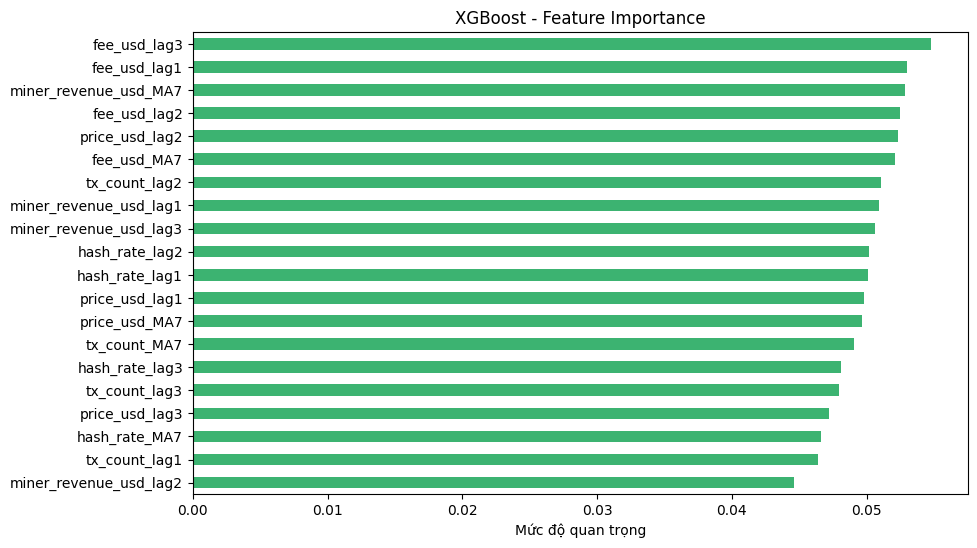

In [9]:
# get feature importance from XGBoost
xgb_model = models["XGBoost"]
importances = xgb_model.feature_importances_


feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='mediumseagreen')
plt.title("XGBoost - Feature Importance")
plt.xlabel("Mức độ quan trọng")
plt.show()

## 2. Second question

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt


df_cluster = df.copy()
cluster_features = ['active_addresses', 'tx_count', 'hash_rate', 'difficulty']
for col in cluster_features:
    ma_90 = df_cluster[col].rolling(window=90).mean()
    df_cluster[f'{col}_momentum'] = df_cluster[col] / ma_90

df_cluster.dropna(inplace=True)


X_cluster_cols = [col for col in df_cluster.columns if 'momentum' in col]
X_cluster = df_cluster[X_cluster_cols]
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

,Thuật toán,Số ngày bất thường phát hiện,Tỷ lệ bất thường (%)
0,DBSCAN,203,5.0074
1,Isolation Forest,203,5.0074


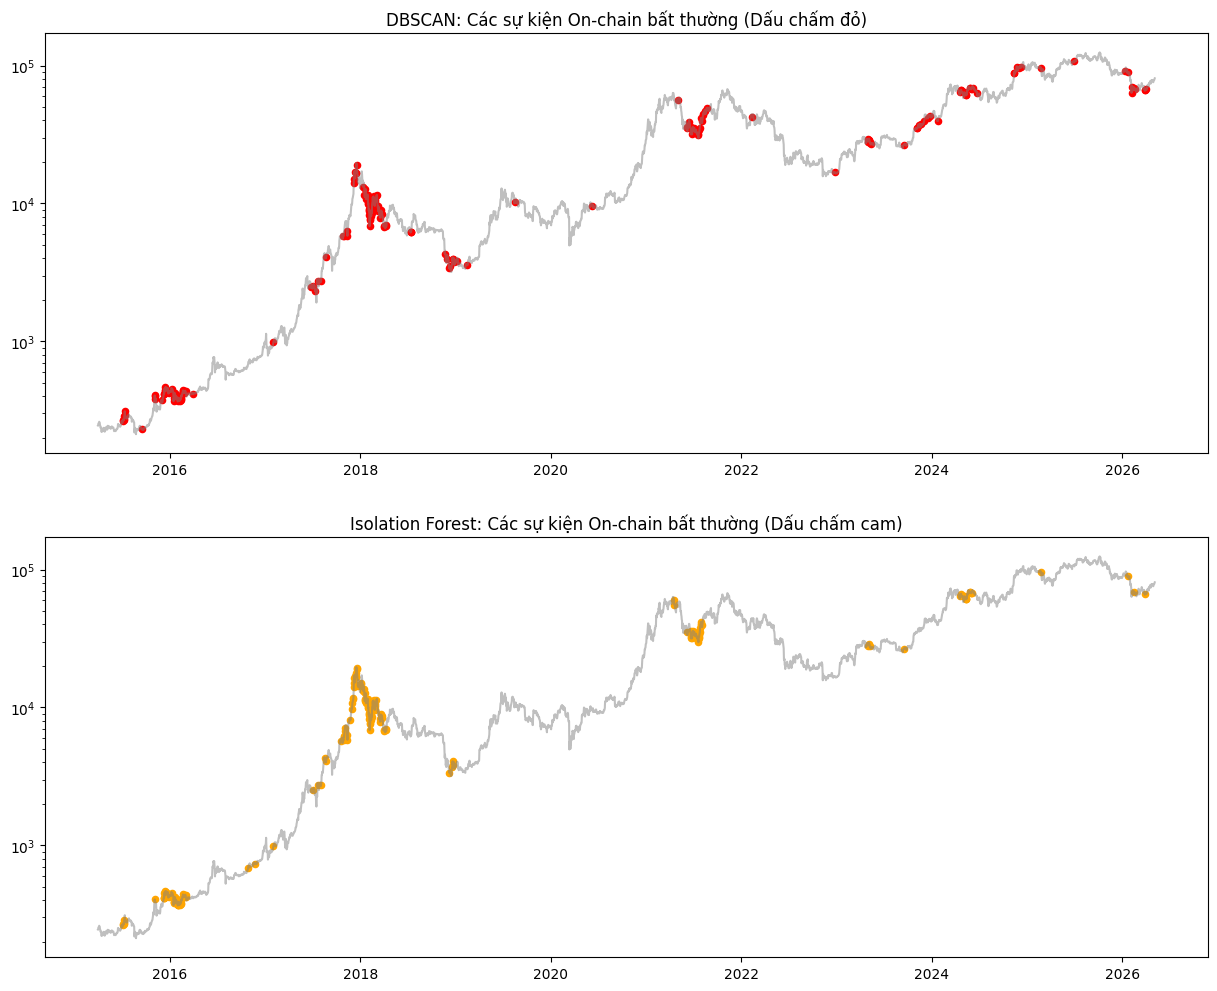

In [12]:

dbscan = DBSCAN(eps=0.8, min_samples=10)
iso_forest = IsolationForest(contamination=0.05, random_state=42) # Giả định 5% số ngày là bất thường

# DBSCAN: -1 là bất thường. Isolation Forest: -1 là bất thường
db_labels = dbscan.fit_predict(X_cluster_scaled)
iso_labels = iso_forest.fit_predict(X_cluster_scaled)

db_anomalies = sum(db_labels == -1)
iso_anomalies = sum(iso_labels == -1)

comparison_q2 = pd.DataFrame({
    'Thuật toán': ['DBSCAN', 'Isolation Forest'],
    'Số ngày bất thường phát hiện': [db_anomalies, iso_anomalies],
    'Tỷ lệ bất thường (%)': [db_anomalies/len(X_cluster_scaled)*100, iso_anomalies/len(X_cluster_scaled)*100]
})
display(comparison_q2)

# Visual
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Plot DBSCAN
axes[0].plot(df_cluster.index, df_cluster['price_usd'], color='gray', alpha=0.5)
axes[0].scatter(df_cluster.index[db_labels == -1], df_cluster['price_usd'][db_labels == -1], color='red', s=20)
axes[0].set_yscale('log')
axes[0].set_title('DBSCAN: Các sự kiện On-chain bất thường (Dấu chấm đỏ)')

# Plot Isolation Forest
axes[1].plot(df_cluster.index, df_cluster['price_usd'], color='gray', alpha=0.5)
axes[1].scatter(df_cluster.index[iso_labels == -1], df_cluster['price_usd'][iso_labels == -1], color='orange', s=20)
axes[1].set_yscale('log')
axes[1].set_title('Isolation Forest: Các sự kiện On-chain bất thường (Dấu chấm cam)')

plt.show()


In [ ]:
db_anomaly_dates = df_cluster.index[db_labels == -1]
iso_anomaly_dates = df_cluster.index[iso_labels == -1]

# Tìm phần giao nhau
common_anomalies = db_anomaly_dates.intersection(iso_anomaly_dates)
overlap_ratio = len(common_anomalies) / len(db_anomaly_dates) * 100

print(f"Có {len(common_anomalies)} ngày được CẢ HAI mô hình đánh giá là bất thường.")
print(f"Mức độ trùng khớp: {overlap_ratio:.2f}%\n")


# 2. ĐÁNH GIÁ ĐỊNH TÍNH
# các sự kiện (Khoảng thời gian +/- 3 ngày quanh sự kiện)
historical_events = {
    '2020-03-12': 'Covid-19 Market Crash',
    '2021-05-19': 'China Mining Ban (Hashrate sập)',
    '2022-11-09': 'Sàn FTX Sụp đổ',
    '2024-01-11': 'SEC Duyệt Bitcoin Spot ETF'
}

eval_list = []
for date_str, event_name in historical_events.items():
    event_date = pd.to_datetime(date_str)
    
    # Kiểm tra xem trong vòng 3 ngày quanh sự kiện
    db_caught = any(abs((db_anomaly_dates - event_date).days) <= 3)
    iso_caught = any(abs((iso_anomaly_dates - event_date).days) <= 3)
    
    eval_list.append({
        'Sự kiện Lịch sử': event_name,
        'Ngày diễn ra': date_str,
        'DBSCAN Phát hiện?': 'Có' if db_caught else 'Không',
        'Isolation Forest Phát hiện?': 'Có' if iso_caught else 'Không'
    })

eval_df = pd.DataFrame(eval_list)
print("BẢNG ĐÁNH GIÁ CHẤT LƯỢNG PHÁT HIỆN BẤT THƯỜNG DỰA TRÊN LỊCH SỬ:")
display(eval_df)


Có 123 ngày được CẢ HAI mô hình đánh giá là bất thường.
Mức độ trùng khớp: 60.59%

BẢNG ĐÁNH GIÁ CHẤT LƯỢNG PHÁT HIỆN BẤT THƯỜNG DỰA TRÊN LỊCH SỬ:


,Sự kiện Lịch sử,Ngày diễn ra,DBSCAN Phát hiện?,Isolation Forest Phát hiện?
0,Covid-19 Market Crash,2020-03-12,Không,Không
1,China Mining Ban (Hashrate sập),2021-05-19,Không,Không
2,Sàn FTX Sụp đổ,2022-11-09,Không,Không
3,SEC Duyệt Bitcoin Spot ETF,2024-01-11,Không,Không


In [16]:
# Xem 15 ngày bất thường gần đây nhất mà cả 2 thuật toán đều đồng thuận
print("CÁC SỰ KIỆN BẤT THƯỜNG CỦA MẠNG LƯỚI (15 sự kiện gần nhất):")
recent_anomalies = sorted(common_anomalies, reverse=True)[:21]

for date in recent_anomalies:
    # Trích xuất dữ liệu của ngày đó để xem cái gì đột biến
    data_of_day = df.loc[date]
    print(f"- Ngày: {date.strftime('%Y-%m-%d')} | Lượng Giao dịch (tx_count): {data_of_day['tx_count']:,.0f} | Hash rate: {data_of_day['hash_rate']:,.0f}")


CÁC SỰ KIỆN BẤT THƯỜNG CỦA MẠNG LƯỚI (15 sự kiện gần nhất):
- Ngày: 2026-03-28 | Lượng Giao dịch (tx_count): 776,246 | Hash rate: 1,157,255,453
- Ngày: 2026-02-15 | Lượng Giao dịch (tx_count): 691,973 | Hash rate: 1,232,582,258
- Ngày: 2026-01-24 | Lượng Giao dịch (tx_count): 284,304 | Hash rate: 690,151,267
- Ngày: 2025-02-23 | Lượng Giao dịch (tx_count): 574,133 | Hash rate: 727,639,381
- Ngày: 2024-06-02 | Lượng Giao dịch (tx_count): 729,457 | Hash rate: 587,247,529
- Ngày: 2024-05-29 | Lượng Giao dịch (tx_count): 721,240 | Hash rate: 574,663,655
- Ngày: 2024-05-26 | Lượng Giao dịch (tx_count): 852,881 | Hash rate: 704,697,039
- Ngày: 2024-05-25 | Lượng Giao dịch (tx_count): 844,733 | Hash rate: 671,140,034
- Ngày: 2024-05-12 | Lượng Giao dịch (tx_count): 562,310 | Hash rate: 545,599,187
- Ngày: 2024-05-10 | Lượng Giao dịch (tx_count): 720,578 | Hash rate: 599,332,435
- Ngày: 2024-05-05 | Lượng Giao dịch (tx_count): 626,139 | Hash rate: 608,775,952
- Ngày: 2024-05-04 | Lượng Giao dị

## Third question

BẢNG SO SÁNH THUẬT TOÁN LUẬT KẾT HỢP:


,Thuật toán,Thời gian chạy (giây),Số lượng Tập phổ biến,Số lượng Luật tìm được
0,Apriori,0.006526,4,2
1,FP-Growth,0.016936,4,2



TOP CÁC SỰ KIỆN ON-CHAIN DẪN ĐẾN GIÁ BỨT PHÁ (Sắp xếp theo độ mạnh Lift):


,antecedents,support,confidence,lift
0,frozenset({fee_usd_Surge}),0.051895,0.212451,1.252038


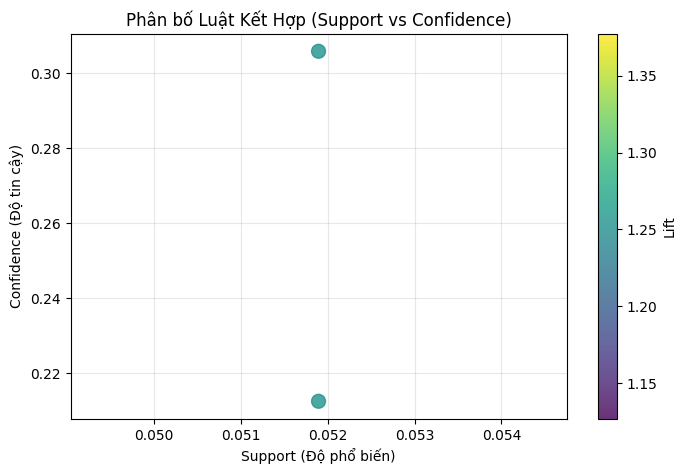

In [ ]:
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import time

# Chuyển đổi dữ liệu số thực thành dạng Boolean (True/False)
df_rules = pd.DataFrame(index=df.index)

# Định nghĩa sự kiện bứt phá của Giá (Ví dụ: Tăng > 5% trong 3 ngày tới)
df_rules['Price_Breakout'] = (df['price_usd'].shift(-3) / df['price_usd'] - 1) > 0.05

# Định nghĩa sự kiện tăng mạnh của On-chain (Hôm nay lớn hơn 1.2 lần MA30)
for col in ['active_addresses', 'tx_count', 'hash_rate', 'fee_usd']:
    ma30 = df[col].rolling(30).mean()
    df_rules[f'{col}_Surge'] = df[col] > (ma30 * 1.2)

df_rules.dropna(inplace=True)

start = time.time()
frequent_itemsets_ap = apriori(df_rules, min_support=0.05, use_colnames=True)
rules_ap = association_rules(frequent_itemsets_ap, metric="lift", min_threshold=1.2)
time_ap = time.time() - start

start = time.time()
frequent_itemsets_fp = fpgrowth(df_rules, min_support=0.05, use_colnames=True)
rules_fp = association_rules(frequent_itemsets_fp, metric="lift", min_threshold=1.2)
time_fp = time.time() - start

comparison_q3 = pd.DataFrame({
    'Thuật toán': ['Apriori', 'FP-Growth'],
    'Thời gian chạy (giây)': [time_ap, time_fp],
    'Số lượng Tập phổ biến': [len(frequent_itemsets_ap), len(frequent_itemsets_fp)],
    'Số lượng Luật tìm được': [len(rules_ap), len(rules_fp)]
})
print("BẢNG SO SÁNH THUẬT TOÁN LUẬT KẾT HỢP:")
display(comparison_q3)

# Visual:consequents là Price_Breakout
breakout_rules = rules_fp[rules_fp['consequents'] == frozenset({'Price_Breakout'})]
breakout_rules = breakout_rules.sort_values('lift', ascending=False).head(10)

print("\nTOP CÁC SỰ KIỆN ON-CHAIN DẪN ĐẾN GIÁ BỨT PHÁ (Sắp xếp theo độ mạnh Lift):")
display(breakout_rules[['antecedents', 'support', 'confidence', 'lift']])

plt.figure(figsize=(8, 5))
plt.scatter(rules_fp['support'], rules_fp['confidence'], c=rules_fp['lift'], cmap='viridis', s=100, alpha=0.8)
plt.colorbar(label='Lift')
plt.title('Phân bố Luật Kết Hợp (Support vs Confidence)')
plt.xlabel('Support (Độ phổ biến)')
plt.ylabel('Confidence (Độ tin cậy)')
plt.grid(True, alpha=0.3)
plt.show()
